# Experiment 2026-06-29 — online single-shot multitrial study

This notebook scales the single-shot online pilot to a small study over two axes:

1. **Topology seed** — different sampled network graphs.
2. **Initial-state seed** — different initial opinion vectors on the same graph.

For every trial, the protocol is unchanged:

- campaign `0`: no control, collect passive data;
- campaigns `1..5`: exploratory online control with decreasing ε;
- campaigns `6..9`: pure λ-mix exploitation.

The primary outcome is **final average network opinion**. The main visual story is:

```text
average-opinion trajectories + online-minus-uniform gap + topology/init heatmaps
```

Minimum opinion, per-node behavior, and action summaries are secondary diagnostics only. They are useful when a dynamics looks strange, especially Hegselmann-Krause clustering, but they are not the control objective.

Oracle is expected to have a head start: it knows the true graph from the first controlled campaign and pays no exploration cost. Therefore the most important practical baseline comparison is **online learned vs uniform**.


## Study design

Each row of the main study is one tuple:

```text
(dynamics, topology_seed, initial_state_seed)
```

For that tuple, all policies start from the same graph and the same `x0`:

- `online_lambda_mix_explore_then_exploit`
- `oracle_true_v`
- `uniform`
- `no_control`

The notebook reports:

- compact final average-opinion table by dynamics;
- win rates against uniform/no-control/oracle;
- average-opinion trajectory curves with confidence bands;
- heatmaps of online-minus-uniform final average opinion over topology × initial-state;
- prediction sanity checks: model MAE relative to identity;
- optional appendix diagnostics for worst-node opinion, actions, and selected per-trial node behavior.

The notebook intentionally avoids aggregating raw node IDs across topology seeds, because node `i` in one sampled graph is not structurally aligned with node `i` in another graph.


In [1]:
# Imports and path setup
from pathlib import Path
import sys
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_repo_root(start=None):
    # Find the repo root by walking upward until opinion_dynamics/ exists.
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError("Could not find repo root containing opinion_dynamics/")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)

from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.experiments.rollouts import make_env_with_dynamics, make_epsilon_schedule
from opinion_dynamics.experiments.online_single_shot import (
    run_single_shot_online_identification,
    rollout_fixed_action_policy,
    trajectory_summary_metrics,
    state_distance_metrics,
)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_55352\1624500449.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Study config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_NAME = "online_single_shot_multitrial"
STUDY_DATE = "2026_06_29"
RESULTS_DIR = REPO_ROOT / "opinion_dynamics" / "experiments" / "results" / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    "hegselmannkrause",
]

# Default is intentionally modest: 3 dynamics × 3 topology seeds × 3 x0 seeds = 27 trials.
# For a smoke test, use [3] and [0]. For a larger study, use e.g. range(10), range(10).
TOPOLOGY_SEEDS = [3, 4, 5, 6, 7]
INITIAL_STATE_SEEDS = [0, 1, 2, 3, 4]

NUM_CAMPAIGNS_TOTAL = 20
EXPLORATION_CAMPAIGNS = 10
T_CAMPAIGN = 0.5
T_S = 0.05

# Match previous total controlled budget:
# old = 9 controlled campaigns * 0.5 = 4.5
TOTAL_CONTROLLED_BUDGET = 4.5
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)

LEARNED_POLICY_LAMBDA = 0.70

EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_SCHEDULE = make_epsilon_schedule(
    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
    exploration_campaigns=EXPLORATION_CAMPAIGNS,
    eps_start=EPSILON_START,
    eps_end=EPSILON_END,
)

assert len(EPSILON_SCHEDULE) == NUM_CAMPAIGNS_TOTAL
assert EPSILON_SCHEDULE[0] == 0.0

# Identification settings.
# The pilot used 2000 steps. For a multitrial scan, 1000 is usually a better first pass.
LR = 1e-3
L2_LAMBDA = 0.0
FIT_MAX_STEPS = 1_000
FIT_MAE_STOP = 5e-3
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 200
IDENTIFIER_KW = {"hidden_dim": 16}

# Initial opinions are generated from the initial_state_seed only, so the same x0 seed
# is reused across topologies and dynamics. This makes the two axes easier to separate.
RANDOM_INITIAL_OPINIONS = True
INITIAL_OPINION_LOW = 0.0
INITIAL_OPINION_HIGH = 1.0
INITIAL_STATE_SEED_BASE = 902_000
TRIAL_RNG_SEED_BASE = 731_000

# Storage controls.
KEEP_TRIAL_ARTIFACTS = False     # set True only for small grids; can use a lot of memory
STORE_FINAL_NODE_TABLES = True
STORE_ACTION_NODE_TABLES = False # action heatmaps for many trials are bulky; enable when debugging

config_summary = {
    "study_name": STUDY_NAME,
    "dynamics": DYNAMICS_LIST,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_state_seeds": INITIAL_STATE_SEEDS,
    "n_trials_expected": len(DYNAMICS_LIST) * len(TOPOLOGY_SEEDS) * len(INITIAL_STATE_SEEDS),
    "num_campaigns": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "B_campaign": B_CAMPAIGN,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
    "epsilon_schedule": EPSILON_SCHEDULE,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
}
config_summary


Using DEVICE: cpu
Results dir: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_29_online_single_shot_multitrial


{'study_name': 'online_single_shot_multitrial',
 'dynamics': ['laplacian', 'coca', 'hegselmannkrause'],
 'topology_seeds': [3, 4, 5, 6, 7],
 'initial_state_seeds': [0, 1, 2, 3, 4],
 'n_trials_expected': 75,
 'num_campaigns': 20,
 't_campaign': 0.5,
 't_s': 0.05,
 'B_campaign': 0.23684210526315788,
 'lambda_mix': 0.7,
 'epsilon_schedule': [0.0,
  1.0,
  0.9,
  0.8,
  0.7,
  0.6,
  0.5,
  0.3999999999999999,
  0.29999999999999993,
  0.19999999999999996,
  0.1,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'fit_max_steps': 1000,
 'fit_mae_stop': 0.005}

## Helper functions

These helpers stay notebook-local. No shared modules are modified.


In [3]:
POLICY_ONLINE = "online_lambda_mix_explore_then_exploit"
POLICY_ORACLE = "oracle_true_v"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"
POLICIES = [POLICY_ONLINE, POLICY_ORACLE, POLICY_UNIFORM, POLICY_NOCONTROL]

POLICY_LABELS = {
    POLICY_ONLINE: "online: explore→exploit λ-mix",
    POLICY_ORACLE: "oracle true-v baseline",
    POLICY_UNIFORM: "uniform baseline",
    POLICY_NOCONTROL: "no-control baseline",
}

POLICY_STYLES = {
    POLICY_ONLINE: dict(marker="o", linestyle="-", linewidth=2.4),
    POLICY_ORACLE: dict(marker="s", linestyle="--", linewidth=2.0),
    POLICY_UNIFORM: dict(marker="^", linestyle="-.", linewidth=2.0),
    POLICY_NOCONTROL: dict(marker="x", linestyle=":", linewidth=2.0),
}


def make_initial_opinions(n, initial_state_seed, low=0.0, high=1.0):
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(initial_state_seed))
    return rng.uniform(float(low), float(high), size=int(n))


def make_trial_rng_seed(dynamics_idx, topology_seed, initial_state_seed):
    return int(TRIAL_RNG_SEED_BASE + 100_000 * dynamics_idx + 1_000 * int(topology_seed) + int(initial_state_seed))


def normalize_nonnegative(v, eps=1e-12):
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    return v / s if s > eps else np.full_like(v, 1.0 / max(1, len(v)))


def l1_normalized_distance(a, b):
    a = normalize_nonnegative(a)
    b = normalize_nonnegative(b)
    return float(np.abs(a - b).sum())


def action_entropy(u, eps=1e-12):
    u = np.asarray(u, dtype=float).reshape(-1)
    total = float(u.sum())
    if total <= eps or len(u) <= 1:
        return np.nan
    p = u[u > eps] / total
    return float(-(p * np.log(p)).sum() / np.log(len(u)))


def campaign_boundary_time(n_states):
    return np.arange(n_states) * T_CAMPAIGN


def add_trajectory_rows(rows, *, trial_meta, policy_name, states):
    states = np.asarray(states, dtype=float)
    for k, x in enumerate(states):
        rows.append({
            **trial_meta,
            "policy": policy_name,
            "boundary_index": int(k),
            "campaign_time": float(k * T_CAMPAIGN),
            "mean_opinion": float(np.mean(x)),
            "min_opinion": float(np.min(x)),
            "max_opinion": float(np.max(x)),
        })


def add_action_rows(rows, *, trial_meta, actions, epsilon_schedule):
    actions = np.asarray(actions, dtype=float)
    eps = np.asarray(epsilon_schedule, dtype=float)
    for k, u in enumerate(actions):
        rows.append({
            **trial_meta,
            "campaign": int(k),
            "epsilon": float(eps[k]) if k < len(eps) else np.nan,
            "budget_used": float(u.sum()),
            "action_support_size": int(np.sum(u > 1e-12)),
            "max_action": float(u.max()) if len(u) else np.nan,
            "action_entropy": action_entropy(u),
        })


def add_action_node_rows(rows, *, trial_meta, actions):
    actions = np.asarray(actions, dtype=float)
    for k, u in enumerate(actions):
        for node, val in enumerate(u):
            rows.append({**trial_meta, "campaign": int(k), "node": int(node), "u": float(val)})


def add_final_node_rows(rows, *, trial_meta, policy_name, states):
    final = np.asarray(states, dtype=float)[-1]
    for node, opinion in enumerate(final):
        rows.append({
            **trial_meta,
            "policy": policy_name,
            "node": int(node),
            "final_opinion": float(opinion),
        })


def add_fit_rows(rows, *, trial_meta, fit_infos):
    for info in fit_infos:
        row = {**trial_meta}
        row.update(info)
        rows.append(row)


def compute_final_identification_row(*, trial_meta, out, A_true, v_true):
    last_fit = out["fit_infos"][-1]
    A_hat = np.asarray(out["A_hats"][-1], dtype=float)
    v_static = out["v_hats_static"][-1]
    v_lambda = out["v_hats_lambda"][-1]
    return {
        **trial_meta,
        "A_MAE_final": float(np.mean(np.abs(A_hat - A_true))),
        "A_Fro_final": float(np.linalg.norm(A_hat - A_true)),
        "v_static_L1_to_true_final": l1_normalized_distance(v_static, v_true),
        "v_lambda_L1_to_true_final": l1_normalized_distance(v_lambda, v_true),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(last_fit["model_over_identity"]),
        "n_pairs_final": int(last_fit["n_pairs"]),
    }


def policy_state_dict(out, oracle, uniform, nocontrol):
    return {
        POLICY_ONLINE: out["states"],
        POLICY_ORACLE: oracle["states"],
        POLICY_UNIFORM: uniform["states"],
        POLICY_NOCONTROL: nocontrol["states"],
    }


## Run the multitrial study

This is the expensive cell. For a first smoke test, reduce the seed lists in the config cell to one topology and one initial-state seed.


In [4]:
env_factory = EnvironmentFactory()

summary_rows = []
fit_rows = []
id_rows = []
trajectory_rows = []
action_rows = []
action_node_rows = []
final_node_rows = []
failed_rows = []
trial_artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

start_all = time.perf_counter()
trial_counter = 0

for dynamics_idx, dynamics in enumerate(DYNAMICS_LIST):
    for topology_seed in TOPOLOGY_SEEDS:
        print("\n" + "=" * 100)
        print(f"Preparing topology: dynamics={dynamics}, topology_seed={topology_seed}")
        print("=" * 100)
        env_template = make_env_with_dynamics(
            env_factory,
            seed=int(topology_seed),
            dynamics_model=dynamics,
        )
        N = int(env_template.num_agents)
        A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
        v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

        for initial_state_seed in INITIAL_STATE_SEEDS:
            trial_counter += 1
            trial_id = f"{dynamics}_topo{topology_seed}_x0{initial_state_seed}"
            trial_meta = {
                "trial_id": trial_id,
                "dynamics": dynamics,
                "topology_seed": int(topology_seed),
                "initial_state_seed": int(initial_state_seed),
                "num_campaigns": int(NUM_CAMPAIGNS_TOTAL),
                "t_campaign": float(T_CAMPAIGN),
                "t_s": float(T_S),
                "B_campaign": float(B_CAMPAIGN),
                "lambda_mix": float(LEARNED_POLICY_LAMBDA),
                "fit_max_steps": int(FIT_MAX_STEPS),
                "fit_mae_stop": float(FIT_MAE_STOP),
            }

            print(f"[{trial_counter:03d}] Running {trial_id}")
            t0 = time.perf_counter()
            try:
                x0 = make_initial_opinions(
                    N,
                    initial_state_seed,
                    low=INITIAL_OPINION_LOW,
                    high=INITIAL_OPINION_HIGH,
                )

                out = run_single_shot_online_identification(
                    env_template,
                    x0=x0,
                    random_initial_opinions=False,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                    B_campaign=B_CAMPAIGN,
                    lambda_mix=LEARNED_POLICY_LAMBDA,
                    exploration_campaigns=EXPLORATION_CAMPAIGNS,
                    epsilon_schedule=EPSILON_SCHEDULE,
                    lr=LR,
                    l2_lambda=L2_LAMBDA,
                    fit_max_steps=FIT_MAX_STEPS,
                    fit_mae_stop=FIT_MAE_STOP,
                    fit_batch_size=FIT_BATCH_SIZE,
                    fit_check_every=FIT_CHECK_EVERY,
                    identifier_kwargs=IDENTIFIER_KW,
                    device=DEVICE,
                    rng_seed=make_trial_rng_seed(dynamics_idx, topology_seed, initial_state_seed),
                )

                oracle = rollout_fixed_action_policy(
                    env_template,
                    x0,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    policy="oracle_true_v",
                    v_true=v_true,
                    zero_first_campaign=True,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                )
                uniform = rollout_fixed_action_policy(
                    env_template,
                    x0,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    policy="uniform",
                    zero_first_campaign=True,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                )
                nocontrol = rollout_fixed_action_policy(
                    env_template,
                    x0,
                    num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                    B_campaign=B_CAMPAIGN,
                    policy="no_control",
                    zero_first_campaign=True,
                    t_campaign=T_CAMPAIGN,
                    t_s=T_S,
                )

                states_by_policy = policy_state_dict(out, oracle, uniform, nocontrol)
                for policy_name, states in states_by_policy.items():
                    row = {**trial_meta, "policy": policy_name, "zero_first_campaign": True}
                    row.update(trajectory_summary_metrics(states, desired_opinion=float(env_template.desired_opinion)))
                    if policy_name != POLICY_ORACLE:
                        row.update(state_distance_metrics(states, oracle["states"], prefix="to_oracle_"))
                    summary_rows.append(row)
                    add_trajectory_rows(trajectory_rows, trial_meta=trial_meta, policy_name=policy_name, states=states)
                    if STORE_FINAL_NODE_TABLES:
                        add_final_node_rows(final_node_rows, trial_meta=trial_meta, policy_name=policy_name, states=states)

                add_fit_rows(fit_rows, trial_meta=trial_meta, fit_infos=out["fit_infos"])
                add_action_rows(action_rows, trial_meta=trial_meta, actions=out["actions"], epsilon_schedule=out["epsilon_schedule"])
                if STORE_ACTION_NODE_TABLES:
                    add_action_node_rows(action_node_rows, trial_meta=trial_meta, actions=out["actions"])
                id_rows.append(compute_final_identification_row(trial_meta=trial_meta, out=out, A_true=A_true, v_true=v_true))

                if KEEP_TRIAL_ARTIFACTS:
                    trial_artifacts[trial_id] = {
                        "out": out,
                        "oracle": oracle,
                        "uniform": uniform,
                        "nocontrol": nocontrol,
                        "A_true": A_true,
                        "v_true": v_true,
                        "x0": x0,
                    }

                elapsed = time.perf_counter() - t0
                print(f"    finished in {elapsed:.1f}s")
            except Exception as exc:
                elapsed = time.perf_counter() - t0
                print(f"    FAILED after {elapsed:.1f}s: {exc}")
                failed_rows.append({
                    **trial_meta,
                    "elapsed_s": float(elapsed),
                    "error_type": type(exc).__name__,
                    "error_message": str(exc),
                    "traceback": traceback.format_exc(),
                })

elapsed_all = time.perf_counter() - start_all
print(f"\nCompleted {trial_counter - len(failed_rows)} / {trial_counter} trials in {elapsed_all / 60:.1f} minutes.")



Preparing topology: dynamics=laplacian, topology_seed=3
[001] Running laplacian_topo3_x00
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
    finished in 1.3s
[002] Running laplacian_topo3_x01
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
    finished in 0.4s
[003] Running laplacian_topo3_x02
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
    finished in 0.4s
[004] Running laplacian_topo3_x03
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
    finished in 0.1s

## Build result tables and save CSVs

The main object is `wide_df`: one row per trial, with signed final-performance gaps.


In [5]:
summary_df = pd.DataFrame(summary_rows)
fit_df = pd.DataFrame(fit_rows)
id_df = pd.DataFrame(id_rows)
trajectory_df = pd.DataFrame(trajectory_rows)
action_df = pd.DataFrame(action_rows)
action_node_df = pd.DataFrame(action_node_rows)
final_node_df = pd.DataFrame(final_node_rows)
failed_df = pd.DataFrame(failed_rows)

if not failed_df.empty:
    print("Failed trials:")
    display(failed_df[["trial_id", "error_type", "error_message"]])

if summary_df.empty:
    raise RuntimeError("No successful trials. Inspect failed_df.")

index_cols = [
    "trial_id",
    "dynamics",
    "topology_seed",
    "initial_state_seed",
    "num_campaigns",
    "t_campaign",
    "t_s",
    "B_campaign",
    "lambda_mix",
]

wide_df = (
    summary_df
    .pivot_table(
        index=index_cols,
        columns="policy",
        values=["mean_end", "min_end", "mean_avg", "min_avg", "final_mean_distance_to_desired"],
        aggfunc="first",
    )
)
wide_df.columns = [f"{metric}__{policy}" for metric, policy in wide_df.columns]
wide_df = wide_df.reset_index()

for metric in ["mean_end", "min_end", "mean_avg", "min_avg", "final_mean_distance_to_desired"]:
    learned = f"{metric}__{POLICY_ONLINE}"
    for baseline_name, baseline_policy in [
        ("oracle", POLICY_ORACLE),
        ("uniform", POLICY_UNIFORM),
        ("nocontrol", POLICY_NOCONTROL),
    ]:
        baseline = f"{metric}__{baseline_policy}"
        if learned in wide_df.columns and baseline in wide_df.columns:
            wide_df[f"learned_minus_{baseline_name}_{metric}"] = wide_df[learned] - wide_df[baseline]

# For distance-to-desired, smaller is better, so add improvement-style deltas too.
if f"final_mean_distance_to_desired__{POLICY_ONLINE}" in wide_df.columns:
    learned_dist = f"final_mean_distance_to_desired__{POLICY_ONLINE}"
    for baseline_name, baseline_policy in [("oracle", POLICY_ORACLE), ("uniform", POLICY_UNIFORM), ("nocontrol", POLICY_NOCONTROL)]:
        baseline_dist = f"final_mean_distance_to_desired__{baseline_policy}"
        if baseline_dist in wide_df.columns:
            wide_df[f"distance_reduction_vs_{baseline_name}"] = wide_df[baseline_dist] - wide_df[learned_dist]

# Save all useful tables.
summary_df.to_csv(RESULTS_DIR / "summary_policy_by_trial.csv", index=False)
wide_df.to_csv(RESULTS_DIR / "wide_trial_performance.csv", index=False)
fit_df.to_csv(RESULTS_DIR / "fit_by_campaign.csv", index=False)
id_df.to_csv(RESULTS_DIR / "identification_by_trial.csv", index=False)
trajectory_df.to_csv(RESULTS_DIR / "trajectory_by_boundary.csv", index=False)
action_df.to_csv(RESULTS_DIR / "online_action_summary_by_campaign.csv", index=False)
if not action_node_df.empty:
    action_node_df.to_csv(RESULTS_DIR / "online_action_by_node_campaign.csv", index=False)
if not final_node_df.empty:
    final_node_df.to_csv(RESULTS_DIR / "final_node_opinions.csv", index=False)
if not failed_df.empty:
    failed_df.to_csv(RESULTS_DIR / "failed_trials.csv", index=False)

print("Saved CSVs to:", RESULTS_DIR)
display(wide_df.head().round(4))


Saved CSVs to: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_06_29_online_single_shot_multitrial


,trial_id,dynamics,topology_seed,initial_state_seed,num_campaigns,t_campaign,t_s,B_campaign,lambda_mix,final_mean_distance_to_desired__no_control,final_mean_distance_to_desired__online_lambda_mix_explore_then_exploit,final_mean_distance_to_desired__oracle_true_v,final_mean_distance_to_desired__uniform,mean_avg__no_control,mean_avg__online_lambda_mix_explore_then_exploit,mean_avg__oracle_true_v,mean_avg__uniform,mean_end__no_control,mean_end__online_lambda_mix_explore_then_exploit,mean_end__oracle_true_v,mean_end__uniform,min_avg__no_control,min_avg__online_lambda_mix_explore_then_exploit,min_avg__oracle_true_v,min_avg__uniform,min_end__no_control,min_end__online_lambda_mix_explore_then_exploit,min_end__oracle_true_v,min_end__uniform,learned_minus_oracle_mean_end,learned_minus_uniform_mean_end,learned_minus_nocontrol_mean_end,learned_minus_oracle_min_end,learned_minus_uniform_min_end,learned_minus_nocontrol_min_end,learned_minus_oracle_mean_avg,learned_minus_uniform_mean_avg,learned_minus_nocontrol_mean_avg,learned_minus_oracle_min_avg,learned_minus_uniform_min_avg,learned_minus_nocontrol_min_avg,learned_minus_oracle_final_mean_distance_to_desired,learned_minus_uniform_final_mean_distance_to_desired,learned_minus_nocontrol_final_mean_distance_to_desired,distance_reduction_vs_oracle,distance_reduction_vs_uniform,distance_reduction_vs_nocontrol
0,coca_topo3_x00,coca,3,0,20,0.5,0.05,0.2368,0.7,0.5300,0.3340,0.3047,0.3467,0.4793,0.5807,0.5951,0.5732,0.4700,0.6660,0.6953,0.6533,0.1095,0.3041,0.1524,0.2914,0.2405,0.6020,0.4150,0.5448,-0.0293,0.0127,0.1960,0.1870,0.0573,0.3615,-0.0144,0.0074,0.1013,0.1517,0.0127,0.1946,0.0293,-0.0127,-0.1960,-0.0293,0.0127,0.1960
1,coca_topo3_x01,coca,3,1,20,0.5,0.05,0.2368,0.7,0.4567,0.3047,0.2758,0.3249,0.5513,0.6322,0.6429,0.6194,0.5433,0.6953,0.7242,0.6751,0.1823,0.4409,0.2279,0.3368,0.3803,0.6460,0.5108,0.5948,-0.0289,0.0202,0.1520,0.1352,0.0512,0.2657,-0.0106,0.0129,0.0809,0.2130,0.1042,0.2586,0.0289,-0.0202,-0.1520,-0.0289,0.0202,0.1520
2,coca_topo3_x02,coca,3,2,20,0.5,0.05,0.2368,0.7,0.4151,0.2948,0.2503,0.3008,0.5682,0.6337,0.6534,0.6271,0.5849,0.7052,0.7497,0.6992,0.3990,0.4753,0.4468,0.4730,0.5345,0.6594,0.6454,0.6596,-0.0445,0.0060,0.1203,0.0140,-0.0002,0.1249,-0.0197,0.0065,0.0655,0.0284,0.0023,0.0762,0.0445,-0.0060,-0.1203,-0.0445,0.0060,0.1203
3,coca_topo3_x03,coca,3,3,20,0.5,0.05,0.2368,0.7,0.6273,0.4383,0.3850,0.4539,0.3838,0.4781,0.5030,0.4706,0.3727,0.5617,0.6150,0.5461,0.1720,0.2899,0.2298,0.2997,0.2815,0.4974,0.4386,0.4992,-0.0533,0.0156,0.1890,0.0588,-0.0018,0.2159,-0.0249,0.0075,0.0943,0.0601,-0.0098,0.1179,0.0533,-0.0156,-0.1890,-0.0533,0.0156,0.1890
4,coca_topo3_x04,coca,3,4,20,0.5,0.05,0.2368,0.7,0.4167,0.2403,0.2195,0.2768,0.5491,0.6431,0.6562,0.6223,0.5833,0.7597,0.7805,0.7232,0.1131,0.3480,0.2933,0.2765,0.2655,0.6587,0.6200,0.5103,-0.0208,0.0365,0.1764,0.0386,0.1484,0.3932,-0.0132,0.0208,0.0940,0.0547,0.0715,0.2348,0.0208,-0.0365,-0.1764,-0.0208,0.0365,0.1764


## Primary aggregate: final average network opinion

This is the main results table. The objective is final average network opinion, so the central quantities are:

- final mean opinion for online/oracle/uniform/no-control;
- online-minus-uniform final mean opinion;
- online-minus-no-control final mean opinion;
- online gap to oracle;
- win rates over the trial grid.


In [6]:
PRIMARY_GAP_COLS = [
    "learned_minus_uniform_mean_end",
    "learned_minus_nocontrol_mean_end",
    "learned_minus_oracle_mean_end",
]
SECONDARY_GAP_COLS = [
    "learned_minus_uniform_min_end",
    "learned_minus_nocontrol_min_end",
    "learned_minus_oracle_min_end",
]
PRIMARY_LEVEL_COLS = [
    f"mean_end__{POLICY_ONLINE}",
    f"mean_end__{POLICY_ORACLE}",
    f"mean_end__{POLICY_UNIFORM}",
    f"mean_end__{POLICY_NOCONTROL}",
]


def mean_ci95(series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    n = int(len(x))
    if n == 0:
        return pd.Series({"mean": np.nan, "std": np.nan, "sem": np.nan, "ci95": np.nan, "n": 0})
    std = float(x.std(ddof=1)) if n > 1 else 0.0
    sem = std / np.sqrt(n) if n > 1 else 0.0
    return pd.Series({"mean": float(x.mean()), "std": std, "sem": sem, "ci95": 1.96 * sem, "n": n})


def summarize_metrics_by_group(df, group_cols, metric_cols):
    rows = []
    for key, group in df.groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        base = dict(zip(group_cols, key))
        for metric in metric_cols:
            if metric not in group.columns:
                continue
            s = mean_ci95(group[metric])
            rows.append({**base, "metric": metric, **s.to_dict()})
    return pd.DataFrame(rows)


def win_rate_by_group(df, group_cols):
    rows = []
    for key, group in df.groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        base = dict(zip(group_cols, key))
        rows.append({
            **base,
            "n_trials": int(len(group)),
            "win_rate_vs_uniform_mean_end": float((group["learned_minus_uniform_mean_end"] > 0).mean()),
            "win_rate_vs_nocontrol_mean_end": float((group["learned_minus_nocontrol_mean_end"] > 0).mean()),
            "win_rate_vs_oracle_mean_end": float((group["learned_minus_oracle_mean_end"] > 0).mean()),
        })
    return pd.DataFrame(rows)


def build_primary_compact_table(wide_df):
    rows = []
    policy_cols = {
        "online": f"mean_end__{POLICY_ONLINE}",
        "oracle": f"mean_end__{POLICY_ORACLE}",
        "uniform": f"mean_end__{POLICY_UNIFORM}",
        "no_control": f"mean_end__{POLICY_NOCONTROL}",
    }
    gap_cols = {
        "online_minus_uniform": "learned_minus_uniform_mean_end",
        "online_minus_no_control": "learned_minus_nocontrol_mean_end",
        "online_minus_oracle": "learned_minus_oracle_mean_end",
    }
    for dynamics, group in wide_df.groupby("dynamics", dropna=False):
        row = {"dynamics": dynamics, "n_trials": int(len(group))}
        for label, col in policy_cols.items():
            s = mean_ci95(group[col])
            row[f"{label}_mean_end"] = s["mean"]
            row[f"{label}_ci95"] = s["ci95"]
        for label, col in gap_cols.items():
            s = mean_ci95(group[col])
            row[f"{label}_mean"] = s["mean"]
            row[f"{label}_ci95"] = s["ci95"]
            row[f"win_rate_{label.replace('online_minus_', 'vs_')}"] = float((group[col] > 0).mean())
        rows.append(row)
    return pd.DataFrame(rows)


primary_compact_df = build_primary_compact_table(wide_df)
primary_by_dynamics = summarize_metrics_by_group(
    wide_df,
    ["dynamics"],
    PRIMARY_LEVEL_COLS + PRIMARY_GAP_COLS,
)
win_by_dynamics = win_rate_by_group(wide_df, ["dynamics"])

print("Primary final average-opinion summary by dynamics")
display(primary_compact_df.round(4))


Primary final average-opinion summary by dynamics


,dynamics,n_trials,online_mean_end,online_ci95,oracle_mean_end,oracle_ci95,uniform_mean_end,uniform_ci95,no_control_mean_end,no_control_ci95,online_minus_uniform_mean,online_minus_uniform_ci95,win_rate_vs_uniform,online_minus_no_control_mean,online_minus_no_control_ci95,win_rate_vs_no_control,online_minus_oracle_mean,online_minus_oracle_ci95,win_rate_vs_oracle
0,coca,25,0.6761,0.0231,0.7323,0.0191,0.6552,0.0234,0.5082,0.0305,0.0209,0.0055,0.92,0.1679,0.0125,1.0,-0.0562,0.0120,0.00
1,hegselmannkrause,25,0.6402,0.0333,0.7177,0.0358,0.6201,0.0208,0.4921,0.0266,0.0201,0.0235,0.72,0.1481,0.0230,1.0,-0.0776,0.0474,0.28
2,laplacian,25,0.6447,0.0314,0.7656,0.0248,0.6368,0.0235,0.5086,0.0317,0.0079,0.0134,0.52,0.1361,0.0127,1.0,-0.1209,0.0244,0.00


## Optional secondary aggregate: worst-node opinion

Minimum opinion is not the primary objective. It is kept as a secondary diagnostic for nonlinear clustering/failure modes, especially Hegselmann-Krause.


In [7]:
SHOW_SECONDARY_TABLES = False

secondary_by_dynamics = summarize_metrics_by_group(
    wide_df,
    ["dynamics"],
    [
        f"min_end__{POLICY_ONLINE}",
        f"min_end__{POLICY_ORACLE}",
        f"min_end__{POLICY_UNIFORM}",
        f"min_end__{POLICY_NOCONTROL}",
    ] + SECONDARY_GAP_COLS,
)

if SHOW_SECONDARY_TABLES:
    display(secondary_by_dynamics.round(5))


## Axis study: topology seed vs initial-state seed

We keep explicit topology and initial-state axes because the online protocol may fail only on particular graphs or particular starting opinion profiles.

The main visualization is a heatmap of **online-minus-uniform final average opinion** for each `(topology_seed, initial_state_seed)` pair.


In [8]:
SHOW_AXIS_TABLES = False

topology_axis_df = summarize_metrics_by_group(
    wide_df,
    ["dynamics", "topology_seed"],
    ["learned_minus_uniform_mean_end", "learned_minus_nocontrol_mean_end", "learned_minus_oracle_mean_end"],
)

initial_state_axis_df = summarize_metrics_by_group(
    wide_df,
    ["dynamics", "initial_state_seed"],
    ["learned_minus_uniform_mean_end", "learned_minus_nocontrol_mean_end", "learned_minus_oracle_mean_end"],
)

if SHOW_AXIS_TABLES:
    print("Topology-axis aggregate: averaged over initial states")
    display(topology_axis_df.round(5))

    print("Initial-state-axis aggregate: averaged over topology seeds")
    display(initial_state_axis_df.round(5))


## Identification and prediction sanity checks

These diagnostics answer a separate question from control performance: did the learned online model become a better one-step predictor than the identity baseline?

The most important diagnostic is:

```text
model_over_identity = learned one-step MAE / identity one-step MAE
```

Values below `1` mean the learned model predicts better than `x_next = x`.


In [9]:
id_metric_cols = [
    "A_MAE_final",
    "A_Fro_final",
    "v_static_L1_to_true_final",
    "v_lambda_L1_to_true_final",
    "final_train_mae",
    "final_identity_mae",
    "final_model_over_identity",
    "n_pairs_final",
]

id_by_dynamics = summarize_metrics_by_group(id_df, ["dynamics"], id_metric_cols)
display(id_by_dynamics.round(5))

fit_campaign_by_dynamics = summarize_metrics_by_group(
    fit_df,
    ["dynamics", "campaign"],
    ["train_mae", "identity_mae", "model_over_identity", "n_pairs"],
)
display(fit_campaign_by_dynamics.head(20).round(5))


,dynamics,metric,mean,std,sem,ci95,n
0,coca,A_MAE_final,0.10725,0.00518,0.00104,0.00203,25.0
1,coca,A_Fro_final,2.60718,0.29782,0.05956,0.11675,25.0
2,coca,v_static_L1_to_true_final,0.66406,0.15599,0.03120,0.06115,25.0
3,coca,v_lambda_L1_to_true_final,0.66421,0.15597,0.03119,0.06114,25.0
4,coca,final_train_mae,0.00120,0.00034,0.00007,0.00013,25.0
5,coca,final_identity_mae,0.00098,0.00017,0.00003,0.00007,25.0
6,coca,final_model_over_identity,1.25926,0.45281,0.09056,0.17750,25.0
7,coca,n_pairs_final,200.00000,0.00000,0.00000,0.00000,25.0
8,hegselmannkrause,A_MAE_final,0.10867,0.00530,0.00106,0.00208,25.0
9,hegselmannkrause,A_Fro_final,2.86544,0.34005,0.06801,0.13330,25.0


,dynamics,campaign,metric,mean,std,sem,ci95,n
0,coca,0,train_mae,0.00315,0.00087,0.00017,0.00034,25.0
1,coca,0,identity_mae,0.00207,0.00050,0.00010,0.00020,25.0
2,coca,0,model_over_identity,1.60362,0.57884,0.11577,0.22691,25.0
3,coca,0,n_pairs,10.00000,0.00000,0.00000,0.00000,25.0
4,coca,1,train_mae,0.00304,0.00079,0.00016,0.00031,25.0
5,coca,1,identity_mae,0.00201,0.00050,0.00010,0.00020,25.0
6,coca,1,model_over_identity,1.60965,0.58313,0.11663,0.22859,25.0
7,coca,1,n_pairs,20.00000,0.00000,0.00000,0.00000,25.0
8,coca,2,train_mae,0.00290,0.00074,0.00015,0.00029,25.0
9,coca,2,identity_mae,0.00194,0.00050,0.00010,0.00020,25.0


## Plot helpers

The main trajectory plot uses average network opinion. Minimum opinion is plotted separately as a secondary diagnostic.


In [10]:
def plot_gap_summary(metric="learned_minus_uniform_mean_end"):
    metric_titles = {
        "learned_minus_uniform_mean_end": "Online − uniform final average opinion",
        "learned_minus_nocontrol_mean_end": "Online − no-control final average opinion",
        "learned_minus_oracle_mean_end": "Online − oracle final average opinion",
    }
    title = metric_titles.get(metric, metric)

    fig, ax = plt.subplots(figsize=(8.8, 3.6))
    sub = summarize_metrics_by_group(wide_df, ["dynamics"], [metric])
    sub = sub[sub["metric"] == metric].copy()
    x = np.arange(len(sub))
    ax.bar(x, sub["mean"], yerr=sub["ci95"], capsize=4)
    ax.axhline(0.0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["dynamics"])
    ax.set_ylabel("final average-opinion gap")
    ax.set_title(f"Main baseline comparison: {title}\nbar = mean over topology × initial-state trials; error bar = 95% CI")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


def plot_average_trajectories(metric="mean_opinion", dynamics_subset=None):
    if dynamics_subset is None:
        dynamics_subset = DYNAMICS_LIST
    ylabel = "average network opinion" if metric == "mean_opinion" else "minimum node opinion"
    title_prefix = "Primary outcome" if metric == "mean_opinion" else "Secondary diagnostic"

    for dynamics in dynamics_subset:
        fig, ax = plt.subplots(figsize=(9.4, 3.8))
        sub_dyn = trajectory_df[trajectory_df["dynamics"] == dynamics].copy()
        for policy in POLICIES:
            sub = sub_dyn[sub_dyn["policy"] == policy]
            if sub.empty:
                continue
            grouped = sub.groupby("boundary_index")[metric].agg(["mean", "std", "count"]).reset_index()
            grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"].clip(lower=1))
            grouped["ci95"] = 1.96 * grouped["sem"].fillna(0.0)
            t = grouped["boundary_index"].to_numpy() * T_CAMPAIGN
            y = grouped["mean"].to_numpy()
            ci = grouped["ci95"].to_numpy()
            ax.plot(t, y, label=POLICY_LABELS[policy], **POLICY_STYLES[policy])
            ax.fill_between(t, y - ci, y + ci, alpha=0.12)
        ax.axvspan(0, T_CAMPAIGN, alpha=0.08, label="campaign 0: no control")
        ax.axvspan(T_CAMPAIGN, (EXPLORATION_CAMPAIGNS + 1) * T_CAMPAIGN, alpha=0.06, label="exploration phase")
        ax.set_xlabel("campaign-boundary time")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title_prefix}: {ylabel} — {dynamics}\nmean over topology × initial-state trials; band = 95% CI")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2, frameon=False)
        fig.subplots_adjust(bottom=0.36)
        plt.show()


def plot_topology_initial_heatmaps(metric="learned_minus_uniform_mean_end"):
    label = "online − uniform final average opinion" if metric == "learned_minus_uniform_mean_end" else metric
    for dynamics in DYNAMICS_LIST:
        sub = wide_df[wide_df["dynamics"] == dynamics].copy()
        if sub.empty:
            continue
        pivot = sub.pivot(index="topology_seed", columns="initial_state_seed", values=metric)
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        im = ax.imshow(pivot.to_numpy(), aspect="auto", interpolation="nearest")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("initial-state seed")
        ax.set_ylabel("topology seed")
        ax.set_title(f"Where does online beat uniform? — {dynamics}\n{label}; positive means online > uniform")
        plt.colorbar(im, ax=ax, label=label)
        plt.show()


def plot_fit_ratio_by_campaign():
    for dynamics in DYNAMICS_LIST:
        sub = fit_df[fit_df["dynamics"] == dynamics].copy()
        if sub.empty:
            continue
        grouped = sub.groupby("campaign")["model_over_identity"].agg(["mean", "std", "count"]).reset_index()
        grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"].clip(lower=1))
        grouped["ci95"] = 1.96 * grouped["sem"].fillna(0.0)
        x = grouped["campaign"].to_numpy()
        y = grouped["mean"].to_numpy()
        ci = grouped["ci95"].to_numpy()
        fig, ax = plt.subplots(figsize=(8.8, 3.2))
        ax.plot(x, y, marker="o")
        ax.fill_between(x, y - ci, y + ci, alpha=0.15)
        ax.axhline(1.0, linewidth=1)
        ax.set_xlabel("campaign index after refit")
        ax.set_ylabel("model MAE / identity MAE")
        ax.set_title(f"Prediction sanity check — {dynamics}\nbelow 1 means learned model beats x_next = x")
        ax.grid(True, alpha=0.3)
        plt.show()


## Primary plots

The main plots are intentionally minimal:

1. online-minus-uniform final average opinion;
2. average network opinion trajectories.

The no-control and oracle gaps remain in the table, but they are not plotted by default because no-control is an easy baseline and oracle is expected to have an advantage.


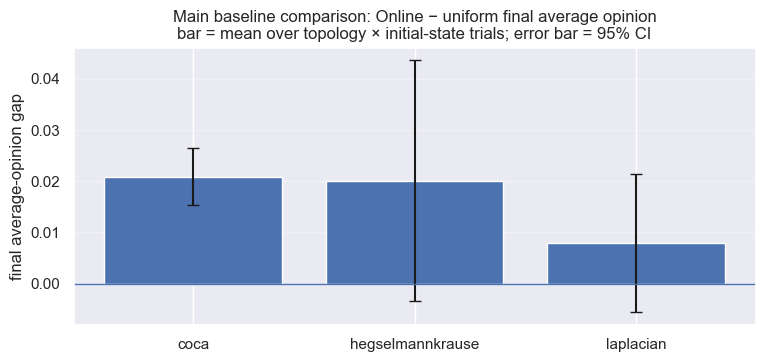

In [11]:
plot_gap_summary("learned_minus_uniform_mean_end")


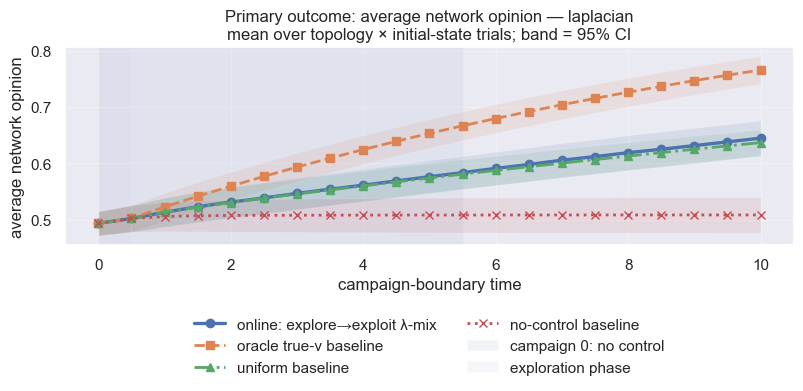

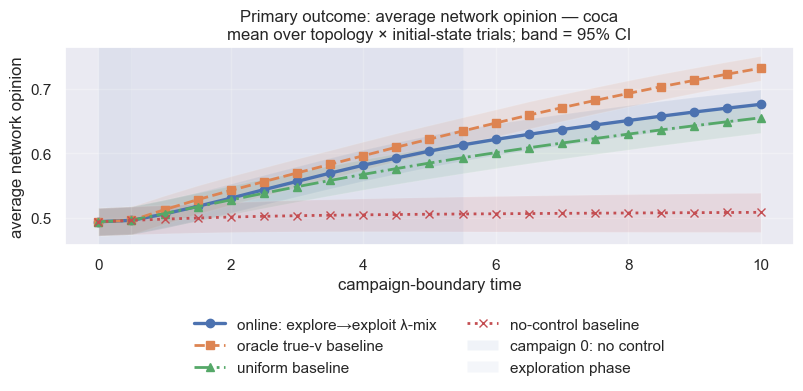

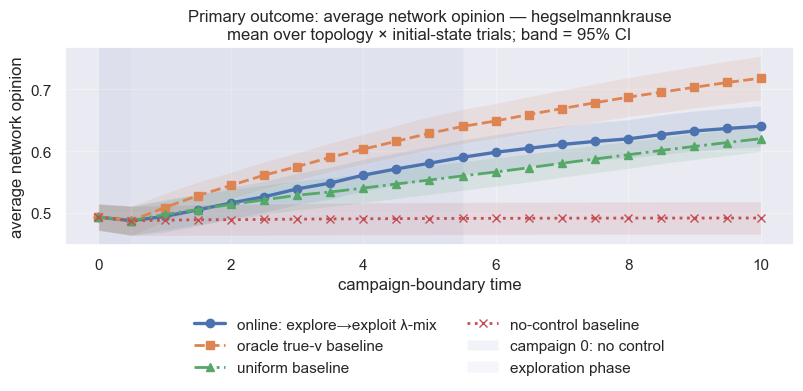

In [12]:
plot_average_trajectories(metric="mean_opinion")


## Axis plots

The heatmaps show whether failures/successes concentrate on particular topology seeds or initial-state seeds.


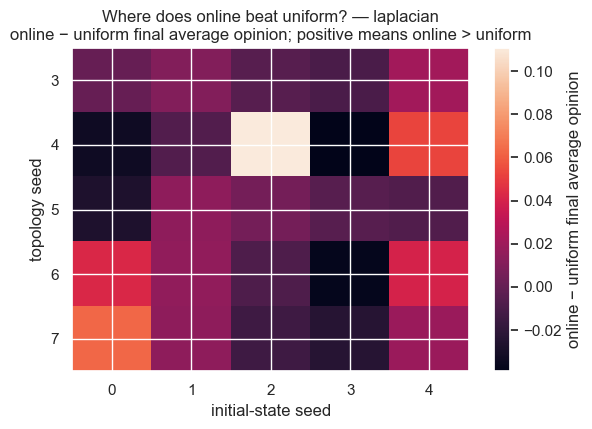

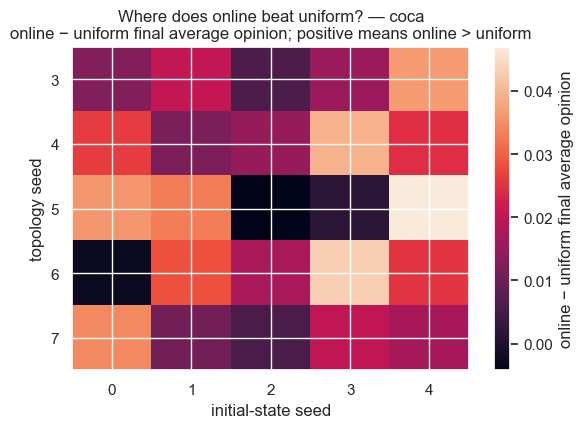

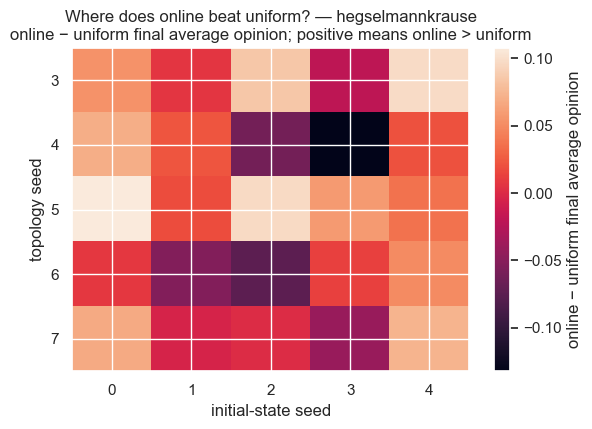

In [13]:
plot_topology_initial_heatmaps(metric="learned_minus_uniform_mean_end")


## Secondary diagnostics

These are not the main control objective. Use them to understand mechanisms/failure modes after the average-opinion results.

- Worst-node trajectories are shown only for Hegselmann-Krause by default, because confidence-threshold clustering can strand low-opinion nodes.
- Prediction-ratio plots check whether the learned model beats identity over the online run.


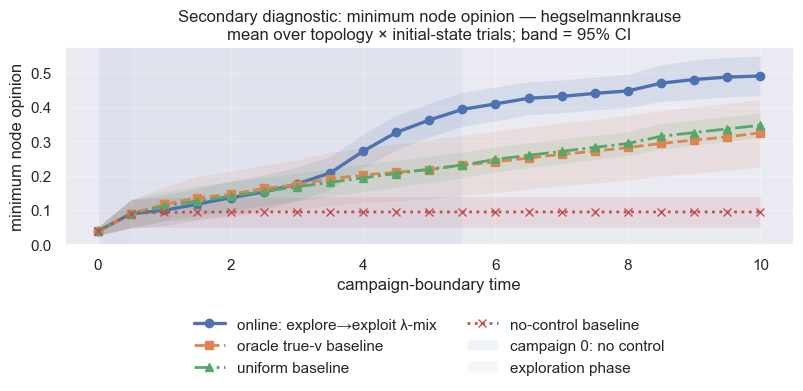

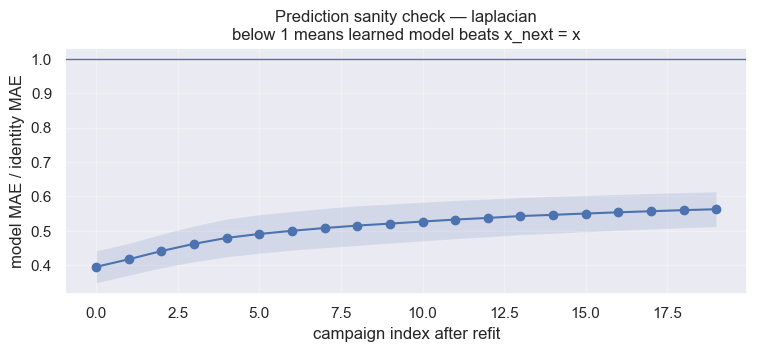

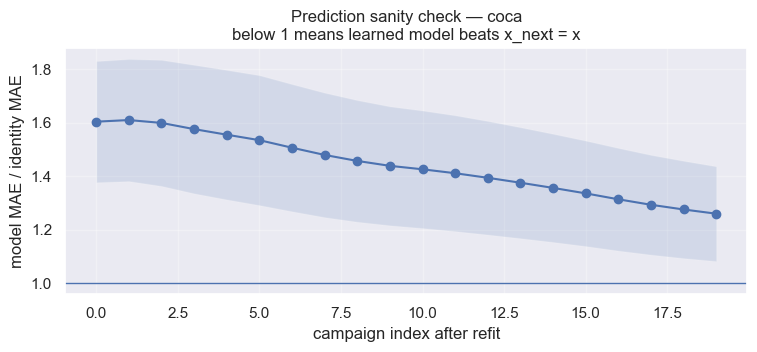

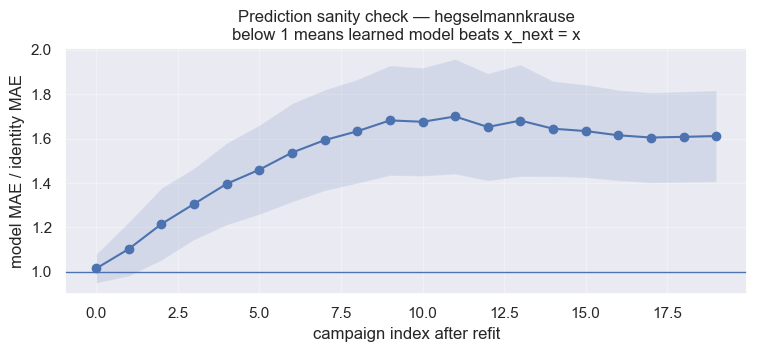

In [14]:
plot_average_trajectories(metric="min_opinion", dynamics_subset=["hegselmannkrause"])
plot_fit_ratio_by_campaign()


## Action diagnostics

These summarize the online run only. Budget-used plots are intentionally omitted because budget use is mostly fixed by design. The table below focuses on action concentration/exploration:

- support size: how many nodes receive nonzero budget;
- max action: largest single-node allocation;
- action entropy: normalized spread of the action over nodes.


In [15]:
action_by_dynamics_campaign = summarize_metrics_by_group(
    action_df,
    ["dynamics", "campaign"],
    ["action_support_size", "max_action", "action_entropy"],
)
display(action_by_dynamics_campaign.round(5))

# Lightweight implementation check: campaign 0 should use no budget.
# Later campaigns usually use B_CAMPAIGN unless all useful actions saturate.
budget_check = (
    action_df.groupby(["dynamics", "campaign"])["budget_used"]
    .agg(["mean", "min", "max", "count"])
    .reset_index()
)
print("Budget-use check, not a main result plot")
display(budget_check.round(5))


,dynamics,campaign,metric,mean,std,sem,ci95,n
0,coca,0,action_support_size,0.00000,0.0,0.0,0.0,25.0
1,coca,0,max_action,0.00000,0.0,0.0,0.0,25.0
2,coca,0,action_entropy,NaN,NaN,NaN,NaN,0.0
3,coca,1,action_support_size,2.00000,0.0,0.0,0.0,25.0
4,coca,1,max_action,0.20000,0.0,0.0,0.0,25.0
...,...,...,...,...,...,...,...,...
175,laplacian,18,max_action,0.20000,0.0,0.0,0.0,25.0
176,laplacian,18,action_entropy,0.15961,0.0,0.0,0.0,25.0
177,laplacian,19,action_support_size,2.00000,0.0,0.0,0.0,25.0
178,laplacian,19,max_action,0.20000,0.0,0.0,0.0,25.0


Budget-use check, not a main result plot


,dynamics,campaign,mean,min,max,count
0,coca,0,0.00000,0.00000,0.00000,25
1,coca,1,0.23684,0.23684,0.23684,25
2,coca,2,0.23684,0.23684,0.23684,25
3,coca,3,0.23684,0.23684,0.23684,25
4,coca,4,0.23684,0.23684,0.23684,25
5,coca,5,0.23684,0.23684,0.23684,25
6,coca,6,0.23684,0.23684,0.23684,25
7,coca,7,0.23684,0.23684,0.23684,25
8,coca,8,0.23684,0.23684,0.23684,25
9,coca,9,0.23684,0.23684,0.23684,25


## Optional selected-trial node diagnostic

Do **not** aggregate raw node IDs across topology seeds. Node `0` in one topology seed is not the same structural object as node `0` in another topology seed.

This cell instead shows final node opinions for one selected trial. Use it only when a specific dynamics/topology/init case looks strange in the aggregate plots.


In [16]:
SELECT_FINAL_NODE_TRIAL_ID = None  # set e.g. "hegselmannkrause_topo3_x0" after inspecting wide_df

if final_node_df.empty:
    print("Final-node table was not stored. Set STORE_FINAL_NODE_TABLES=True and rerun.")
else:
    if SELECT_FINAL_NODE_TRIAL_ID is None:
        # Default to a Hegselmann-Krause trial if available; otherwise use the first trial.
        candidates = wide_df[wide_df["dynamics"] == "hegselmannkrause"]
        if candidates.empty:
            selected_trial_id = str(wide_df.iloc[0]["trial_id"])
        else:
            # Pick a trial near the median online-minus-uniform gap, not the most extreme case.
            candidates = candidates.copy()
            med = candidates["learned_minus_uniform_mean_end"].median()
            selected_idx = (candidates["learned_minus_uniform_mean_end"] - med).abs().idxmin()
            selected_trial_id = str(candidates.loc[selected_idx, "trial_id"])
        print("SELECT_FINAL_NODE_TRIAL_ID was None; showing representative trial:", selected_trial_id)
    else:
        selected_trial_id = SELECT_FINAL_NODE_TRIAL_ID

    sub = final_node_df[final_node_df["trial_id"] == selected_trial_id].copy()
    if sub.empty:
        print(f"No final-node rows found for trial_id={selected_trial_id!r}.")
    else:
        pivot = sub.pivot(index="node", columns="policy", values="final_opinion")
        if POLICY_NOCONTROL in pivot.columns:
            pivot = pivot.sort_values(POLICY_NOCONTROL)
        display(pivot.round(4))


SELECT_FINAL_NODE_TRIAL_ID was None; showing representative trial: hegselmannkrause_topo4_x04


policy,no_control,online_lambda_mix_explore_then_exploit,oracle_true_v,uniform
node,,,,
5,0.0226,0.5411,0.6176,0.2776
3,0.0226,0.5425,0.6235,0.2776
14,0.0226,0.5443,0.6309,0.2776
9,0.1415,0.5408,0.1415,0.3656
8,0.2072,0.5113,0.2072,0.4141
11,0.2174,0.5402,0.2174,0.6396
13,0.5129,0.5129,0.5129,0.6400
0,0.5129,0.5387,0.6070,0.6397
1,0.5129,0.5402,0.6138,0.6396


## Interpretation checklist

Use the notebook in this order:

1. **Primary compact table:** final average opinion, gaps, and win rates by dynamics.
2. **Average-opinion trajectories:** do online, uniform, no-control, and oracle separate over time?
3. **Online-minus-uniform plot:** does the online protocol beat the robust uniform baseline on average?
4. **Topology × initial-state heatmaps:** are failures topology-specific or initial-state-specific?
5. **Prediction diagnostics:** does the model beat identity during/after the online run?
6. **Appendix diagnostics:** use worst-node and selected-node views only to explain nonlinear cluster behavior.

Suggested first claims to write down after a run:

```text
For each dynamics, online learned control improves over no-control by X ± CI in final average opinion.
Compared to uniform, it wins on Y% of trials and has mean gap Z ± CI.
The oracle gap remains negative, as expected, because oracle knows the true graph and does not explore.
```
